# MK Praktikum Unggulan Universitas Gunadarma
# Mata Kuliah: Praktikum Teknologi Kecerdasan Artifisial (Tingkat 1)

---

# Pertemuan VII

## Object Detection with TensorFlow Hub (EfficientDet)

### Pengenalan
Deteksi objek adalah teknologi yang berada di bawah domain Computer Vision yang lebih luas. Metode ini berkaitan dengan mengidentifikasi dan melacak objek yang ada dalam gambar dan video. Deteksi objek memiliki banyak aplikasi seperti deteksi wajah, deteksi kendaraan, penghitungan pejalan kaki, mobil tanpa pengemudi, sistem keamanan, dll.

Pada materi kali ini, kita akan menggunakan **TensorFlow Hub** dengan model **EfficientDet-Lite0**. Model ini dirancang untuk sangat efisien dan ringan, sehingga cocok dijalankan di lingkungan CPU tanpa memerlukan Resource GPU yang besar.

### 1. Menyiapkan environment

Proses ini akan memastikan versi kode akan berjalan di model CPU only agar tidak terjadi error memori atau konflik library.

In [12]:
import os
import gc
import tensorflow as tf

# Paksa mode only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.keras.backend.clear_session()
gc.collect()

print("Environment siap.")

Environment siap.


---
### 2. Import Package

Impor library TensorFlow Hub, Pillow untuk pemrosesan gambar, serta Matplotlib untuk visualisasi hasil.

In [13]:
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import gc

### 3. Load Model Pre-trained
Kita akan mengunduh model **EfficientDet-Lite0** langsung dari TensorFlow Hub.

In [14]:
model_url = "https://tfhub.dev/tensorflow/efficientdet/lite0/detection/1"

if 'detector' not in globals():
    print("Memuat model ke memori... Mohon tunggu.")
    detector = hub.load(model_url)
    print("Model berhasil dimuat.")
else:
    print("Model sudah tersedia di memori.")

Model sudah tersedia di memori.


### 4. Menentukan Gambar Input

Mari tentukan gambar input yang akan dideteksi oleh model.

In [15]:
input_path = "image-2.jpg"

### 5. Menjalankan Deteksi Objek

Pada bagian ini, kita membuka gambar, melakukan resize otomatis untuk keamanan memori (RAM), dan mengirimkan data gambar ke model untuk dideteksi.

In [16]:
raw_img = Image.open(input_path)

# Deteksi versi filter Pillow (LANCZOS)
try:
    resampling_filter = Image.Resampling.LANCZOS
except AttributeError:
    resampling_filter = Image.LANCZOS

# Gunakan thumbnail untuk menjaga aspect ratio dan memori
raw_img.thumbnail((1024, 1024), resampling_filter)
img_array = np.array(raw_img)

input_tensor = tf.convert_to_tensor(img_array)
input_tensor = input_tensor[tf.newaxis, ...]

results = detector(input_tensor)
print(f"Deteksi selesai. Ukuran gambar proses: {img_array.shape}")

Deteksi selesai. Ukuran gambar proses: (640, 1024, 3)


### 6. Cek Output dan Visualisasi Hasil

Terakhir, kita akan menggambarkan kotak (bounding box) di sekitar objek yang terdeteksi dan menampilkan nama label beserta tingkat probabilitasnya.

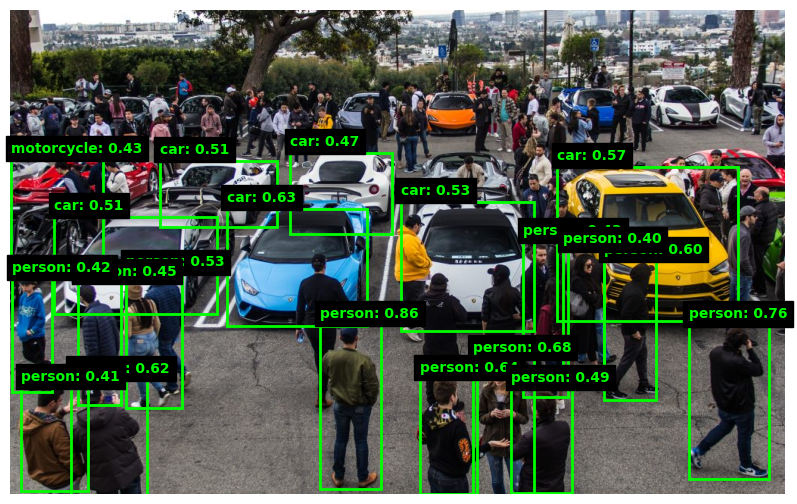

2684

In [17]:
plt.close('all')

# Kelas objek 7 dan threshold deteksi
labels = {1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 6: 'bus', 8: 'truck', 10: 'traffic light'}
threshold = 0.4

boxes = results[0][0].numpy()
scores = results[1][0].numpy()
classes = results[2][0].numpy()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_array)
h, w, _ = img_array.shape

# Deteksi koordinat (Normalized vs Pixel)
is_normalized = np.max(boxes) <= 1.01

for i in range(len(scores)):
    if scores[i] >= threshold:
        ymin, xmin, ymax, xmax = boxes[i]

        if is_normalized:
            left, top, right, bottom = xmin * w, ymin * h, xmax * w, ymax * h
        else:
            left, top, right, bottom = xmin, ymin, xmax, ymax

        if right > left and bottom > top:
            rect = patches.Rectangle((left, top), right - left, bottom - top,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)

            label_name = labels.get(int(classes[i]), f'ID {int(classes[i])}')
            ax.text(left, top - 10, f"{label_name}: {scores[i]:.2f}",
                    color='lime', fontsize=10, weight='bold', backgroundcolor='black')

plt.axis('off')
plt.show()
gc.collect()

### **Tugas Praktikum**

1. Ganti nilai `input_path` dengan `image-2.jpg`.
2. Jalankan cell berurutan dari import library sampai dengan visualisasi.
3. Lihat hasil kotak hijau, label objek, dan nilai confidence.
4. Tulis kesimpulan singkat: objek apa saja terdeteksi, mana yang paling akurat, dan apakah ada kemungkinan error (objek kecil/gelap/tertutup).
5. Konversi file notebook serta penjelasan dan kesimpulannya menjadi file PDF.

<div class="alert alert-warning">
<strong>Perhatian!</strong> Berikut merupakan cara konversi File IPYNB menjadi File PDF untuk melakukan pengumpulan tugas di Virtual Class.
    <a href="https://youtu.be/qXELXtnAK7c">Video konversi</a>.
    </div>

---


Copyright © Pengelola MK Praktikum Unggulan (Praktikum DGX), Universitas Gunadarma


https://www.praktikum-hpc.gunadarma.ac.id/